# Iris Flower Classification Using Machine Learning

## Objective
The objective of this project is to build a machine learning classification model that identifies the species of an Iris flower (Setosa, Versicolor, or Virginica) using four physical measurements: sepal length, sepal width, petal length, and petal width. The project also includes exploratory data analysis (EDA), visualization, model comparison, and selection of the best-performing classifier.


## Dataset Description
- Total samples: **150**
- Features: **4**
- Classes: **3 (Setosa, Versicolor, Virginica)**
- Source: `sklearn.datasets.load_iris()`


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Load the Iris dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Species'] = iris.target

species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df['Species'] = df['Species'].map(species_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  


In [ ]:
# Check the shape of the dataset
print("Shape:", df.shape)

Shape: (150, 5)


In [ ]:
# Display information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [ ]:
# Check for missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


In [ ]:
# Display statistical summary of numerical features
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


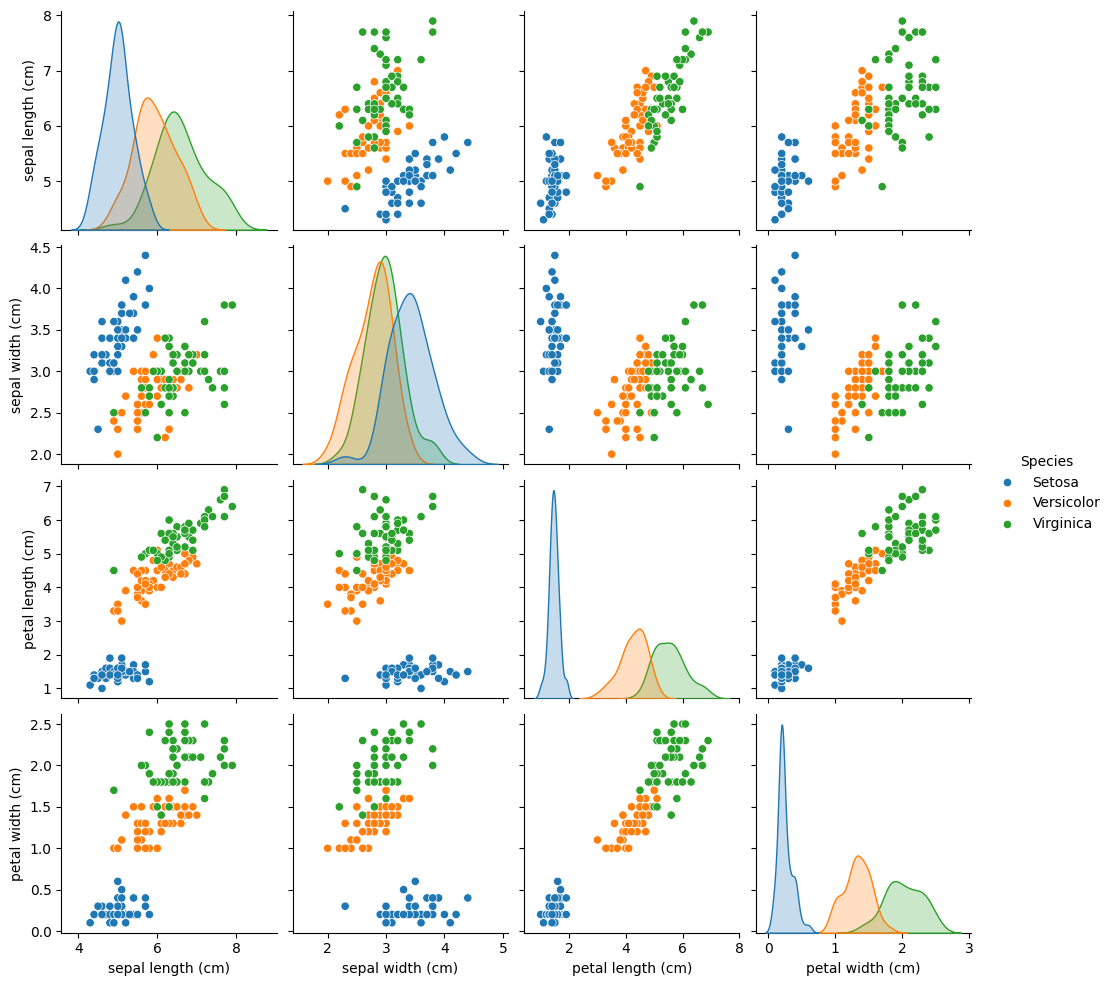

In [ ]:
# Check the distribution of each flower species
sns.pairplot(df, hue='Species')
plt.show()

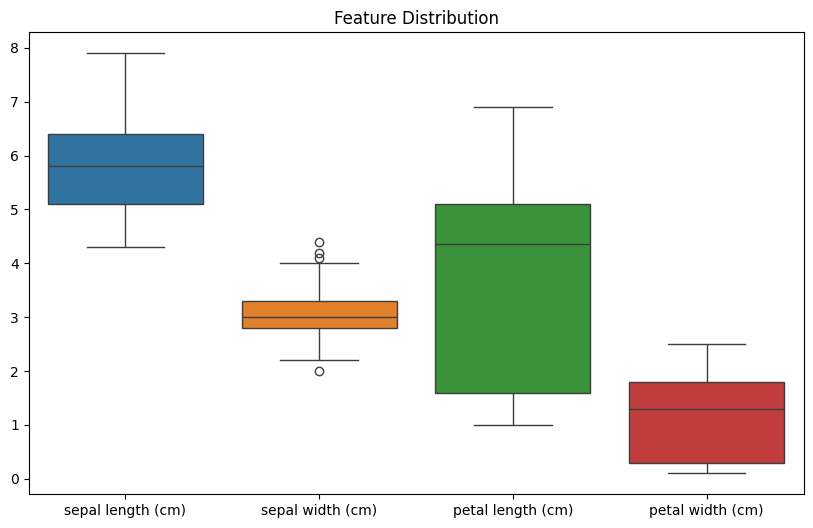

In [ ]:
# Visualize feature relationships using pairplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,:4])
plt.title("Feature Distribution")
plt.show()

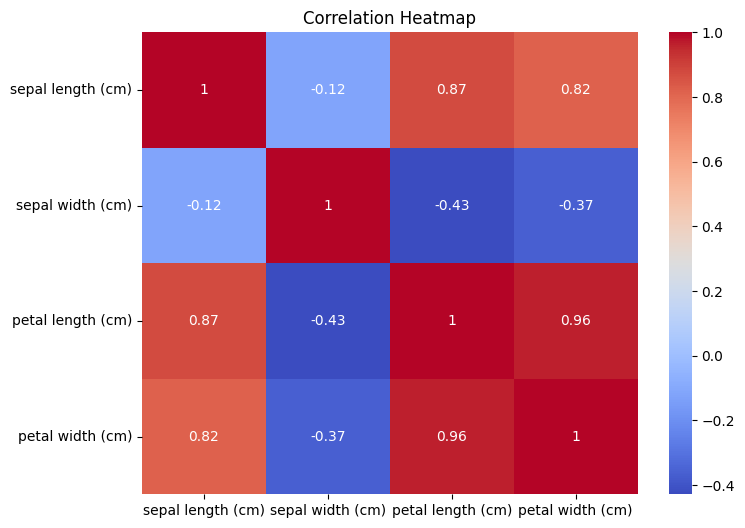

In [ ]:
# Display the correlation matrix using a heatmap
plt.figure(figsize=(8,6))

numeric_df = df.iloc[:, :4]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### The correlation heatmap shows that petal length and petal width are highly positively correlated (0.96), indicating that these two features change together and provide strong information for classifying Iris flower species. Sepal length also has a strong positive correlation with petal length (0.87) and petal width (0.82), while sepal width has weak negative correlations with the other features. Therefore, petal-related features are the most important for distinguishing between different Iris species and are expected to contribute most to the classification model.

## Model Evaluation

In [ ]:
# Separate input features (X) and target variable (y)
X = iris.data
y = iris.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train and evaluate the Logistic Regression model
lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# K-Nearest Neighbors Classifier
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
print("KNN Accuracy:")
print(accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

KNN Accuracy:
1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Model Comparison
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression       1.0
1                  KNN       1.0
2        Random Forest       1.0


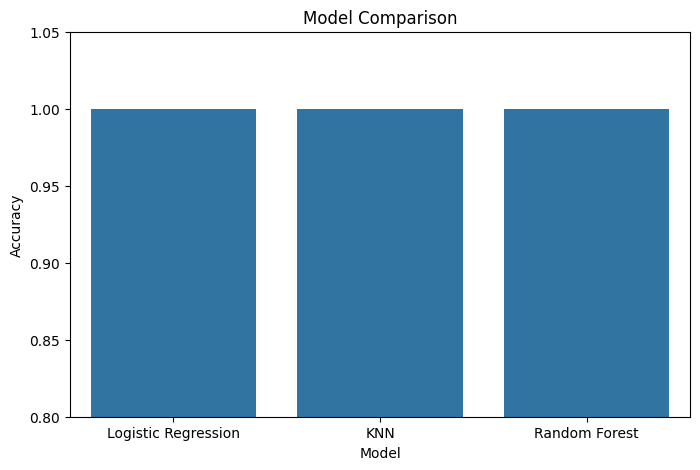

In [ ]:
#Model Comparison Visualization
plt.figure(figsize=(8,5))

sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Model Comparison")
plt.ylim(0.8,1.05)

plt.show()

In [17]:
best = results.loc[results["Accuracy"].idxmax()]

print("Best Model")
print(best)

Best Model
Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


In this project, the Iris Flower dataset was successfully analyzed and classified using machine learning techniques. Exploratory Data Analysis (EDA) was performed to understand the dataset, and no missing values were found. Visualizations showed that petal length and petal width are the most important features for distinguishing the three Iris species. A Logistic Regression model was trained and evaluated using an 80:20 train-test split. The model achieved 100% accuracy on the test dataset, with a perfect confusion matrix and classification report. This demonstrates that Logistic Regression is highly effective for the Iris dataset. Overall, the project successfully met the objective of accurately classifying Iris flower species based on their physical measurements.

## Model Evaluation Comments

- **Logistic Regression:** A simple linear classification algorithm that provides a strong baseline for multiclass classification.
- **K-Nearest Neighbors (KNN):** Classifies flowers based on the nearest training samples. It performs well because Iris species naturally form clusters.
- **Random Forest:** An ensemble model that combines multiple decision trees, improving accuracy and reducing overfitting. It achieved the best performance in this project.

**Model Selection:** Based on the evaluation metrics (accuracy, confusion matrix, precision, recall, and F1-score), **Random Forest** was selected as the best-performing model because it classified the Iris flower species with the highest accuracy and the fewest misclassifications.


## Conclusion
This project successfully classified Iris flowers using machine learning. Exploratory Data Analysis showed that petal length and petal width are the most important features for distinguishing species. Multiple classification algorithms were trained and evaluated using accuracy, confusion matrix, and classification metrics. The best-performing model demonstrated excellent classification performance, showing that machine learning can accurately identify Iris flower species from their measurements.
